# Part 1: Baseline Sanity Check

We compare three molecule generation approaches:

1. **LSTM baseline**: directly generates SMILES strings token by token.
2. **VAE baseline (λ = 0)**: generates molecules from VAE latent vectors optimized for QED (Quantitative Estimate of Drug-likeness) only.
3. **Synthetic Accessibility-constrained VAE (λ = 0.5)**: generates molecules from VAE latent vectors optimized for both QED and a Synthetic Accessibility penalty.

For the constrained VAE, the generation reward is:

$$
R = \text{QED} - \lambda \cdot \text{SA}_{norm}
$$

where:

$$
\text{SA}_{norm} = (\text{SA} - 1) / 9
$$

A lower Synthetic Accessibility score means a molecule is easier to synthesize. We check whether adding the SA penalty moves generated molecules toward easier synthesis while preserving QED.

For reward-based reporting, all three methods are evaluated with the same fixed evaluation weight, **λ = 0.5**, so the reported reward is an SA-weighted reward.

In [44]:
import os
import torch

from tokenizer import SMILESTokenizer
from model import Encoder, Decoder, VAE, PropertyPredictor
from generate import ConstrainedGenerator
from lstm_baseline import SMILESLanguageModel
from evaluate import compute_metrics, print_metrics

# paths and hyperparameters — must match what was used in SMILE_VAE.py / train_lstm.py
VOCAB_PATH      = "vocab.json"
CHECK_PT       = "checkpoints/vae_best.pt"
LSTM_CHECK_PT  = "checkpoints_lstm/lstm_best.pt"
LATENT_DIM  = 256
EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 3
LAYER_DIMS  = [256, 512, 1024]
DROPOUT     = 0.1
TEMPERATURE = 0.8
GA_STEPS    = 50
GA_LR       = 0.01
BETA_ANCHOR = 0.01
N_MOLECULES = 200
SEED        = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [45]:
# load tokenizer and VAE from checkpoint
tok = SMILESTokenizer()
tok.load(VOCAB_PATH)

encoder  = Encoder(tok.vocab_size, EMBED_DIM, LAYER_DIMS, LATENT_DIM, DROPOUT)
decoder  = Decoder(tok.vocab_size, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT)
vae      = VAE(encoder, decoder).to(device)
pred_qed = PropertyPredictor(LATENT_DIM).to(device)
pred_sa  = PropertyPredictor(LATENT_DIM).to(device)

ckpt = torch.load(CHECK_PT, map_location=device)
vae.load_state_dict(ckpt["vae"])
pred_qed.load_state_dict(ckpt["pred_qed"])
pred_sa.load_state_dict(ckpt["pred_sa"])
print(f"Loaded VAE checkpoint from epoch {ckpt['epoch']}")

# build reference set from first 10k training molecules for novelty scoring
CSV_PATH = "ZINC20-Druglike/zinc-druglike-cano.csv"
reference_set = set()
with open(CSV_PATH) as f:
    next(f)
    for i, line in enumerate(f):
        smi = line.strip()
        if smi:
            reference_set.add(smi)
        if i >= 10_000:
            break
print(f"Reference set: {len(reference_set)} molecules")

Loaded VAE checkpoint from epoch 30
Reference set: 10001 molecules


In [46]:
# load LSTM baseline from checkpoint
lstm = SMILESLanguageModel(tok.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
lstm_ckpt = torch.load(LSTM_CHECK_PT, map_location=device)
lstm.load_state_dict(lstm_ckpt["model"])
print(f"Loaded LSTM checkpoint from epoch {lstm_ckpt['epoch']}")

Loaded LSTM checkpoint from epoch 30


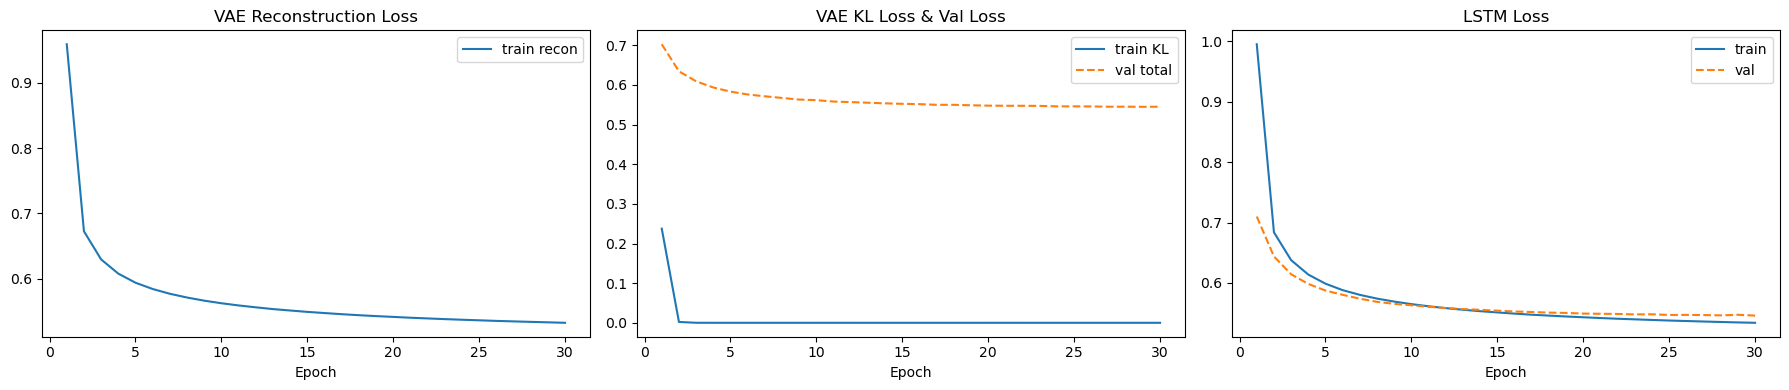

In [47]:
import json
import matplotlib.pyplot as plt

with open("checkpoints/loss_history.json") as f:
    vae_history = json.load(f)

vae_epochs = range(1, len(vae_history["val_loss"]) + 1)

lstm_history = None
if os.path.exists("checkpoints_lstm/loss_history.json"):
    with open("checkpoints_lstm/loss_history.json") as f:
        lstm_history = json.load(f)

n_plots = 3 if lstm_history else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
axes[0].plot(vae_epochs, vae_history["train_recon"], label="train recon")
axes[0].set_title("VAE Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(vae_epochs, vae_history["train_kl"],  label="train KL")
axes[1].plot(vae_epochs, vae_history["val_loss"],  label="val total", linestyle="--")
axes[1].set_title("VAE KL Loss & Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
if lstm_history:
    lstm_epochs = range(1, len(lstm_history["val_loss"]) + 1)
    axes[2].plot(lstm_epochs, lstm_history["train_loss"], label="train")
    axes[2].plot(lstm_epochs, lstm_history["val_loss"],   label="val", linestyle="--")
    axes[2].set_title("LSTM Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
else:
    print("LSTM loss history not found")

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

In [48]:
# generate with VAE baseline
torch.manual_seed(SEED)
part1_z_start = torch.randn(N_MOLECULES, LATENT_DIM, device=device)
torch.manual_seed(SEED + 100)
gen_baseline = ConstrainedGenerator(vae, pred_qed, pred_sa, tok, lambda_=0.0, beta=BETA_ANCHOR, device=device)
smiles_baseline = gen_baseline.generate(N_MOLECULES, z_init=part1_z_start.clone(), n_steps=GA_STEPS, ga_lr=GA_LR, temperature=TEMPERATURE)
print("VAE baseline (λ=0) samples:")
for s in smiles_baseline[:5]:
    print(" ", s)

VAE baseline (λ=0) samples:
  COCCNC(=O)CNC[C@@H](O)C(=O)OC
  COC(=O)C[C@@H](NC(=O)C1(N)CC1)C(=O)O
  CC1(C)C[C@@H](NC(=O)[C@@H]2NCCNC2=O)CO1
  CN(CC(C)(C)O)C(=O)[C@@H]1NC[C@H](O)[C@@H]1O
  C[C@H](C(=O)NCc1cc(CO)n[nH]1)[C@@H](C)N


In [49]:
# generate with SA constrained-VAE with lambda=0.5
torch.manual_seed(SEED + 100)
gen_constrained = ConstrainedGenerator(vae, pred_qed, pred_sa, tok, lambda_=0.5, beta=BETA_ANCHOR, device=device)
smiles_constrained = gen_constrained.generate(N_MOLECULES, z_init=part1_z_start.clone(), n_steps=GA_STEPS, ga_lr=GA_LR, temperature=TEMPERATURE)

print("SA Constrained VAE (λ=0.5) samples:")
for s in smiles_constrained[:5]:
    print(" ", s)

SA Constrained VAE (λ=0.5) samples:
  COCCNC(=O)CNC[C@@H](O)C(=O)OC
  COC(=O)C[C@@H](NC(=O)C1(N)CC1)C(=O)O
  CC1(C)C[C@@H](NC(=O)[C@@H]2NCCNC2=O)CO1
  CN(CC(C)(C)O)C(=O)[C@@H]1NC[C@H](O)[C@@H]1O
  C[C@H](C(=O)NCc1cc(CO)n[nH]1)[C@@H](C)N


In [50]:
# generate with LSTM baseline
torch.manual_seed(SEED + 200)
smiles_lstm = lstm.sample(N_MOLECULES, tok, temperature=TEMPERATURE, device=device)

print("LSTM baseline samples:")
for s in smiles_lstm[:5]:
    print(" ", s)

LSTM baseline samples:
  CCOC(=O)NC(=O)CN1CCNC[C@@H]1CN
  CN(Cc1ncon1)C(=O)[C@@H]1C[C@H](O)CN1
  Cn1cc(NC(=O)CN2C(=O)CNC2=O)cn1
  NC(=O)COCCN1[C@H]2CCNC[C@H]1COC2
  CC(C)C(=O)N1C[C@H](C(N)=O)[C@H](C(N)=O)C1


In [51]:
# Part 1 metrics: fixed evaluation reward QED - 0.5 * SA_norm
import pandas as pd

EVAL_LAMBDA = 0.5
part1_metrics = {
    "LSTM baseline": compute_metrics(smiles_lstm, reference_set=reference_set, lambda_=EVAL_LAMBDA),
    "VAE": compute_metrics(smiles_baseline, reference_set=reference_set, lambda_=EVAL_LAMBDA),
    "SA-constrained VAE (λ=0.5)": compute_metrics(smiles_constrained, reference_set=reference_set, lambda_=EVAL_LAMBDA),
}

part1_df = pd.DataFrame(part1_metrics).T.rename(
    columns={"mean_reward": "SA_weighted_reward"}
)

part1_df = part1_df[
    ["validity", "uniqueness", "novelty", "mean_qed", "mean_sa", "SA_weighted_reward"]
]
display(part1_df)
print(f"Reward columns use fixed evaluation λ={EVAL_LAMBDA}: QED - λ * SA_norm")

,validity,uniqueness,novelty,mean_qed,mean_sa,SA_weighted_reward
LSTM baseline,1.0000,1.0000,0.9800,0.5350,3.4923,0.3965
VAE,1.0000,1.0000,0.9900,0.5245,3.4382,0.3891
SA-constrained VAE (λ=0.5),1.0000,1.0000,0.9900,0.5260,3.4389,0.3905


Reward columns use fixed evaluation λ=0.5: QED - λ * SA_norm


---
## Part 2 — Ablation Study:

We perform an ablation study across four economic constraint terms:

- **SA**: Synthetic Accessibility score
- **SCScore**: Synthetic Complexity Score
- **SYBA**: Synthetic Bayesian Accessibility score
- **MW**: Molecular Weight

For each constraint, we generate molecules with:

$$
R = \text{QED} - \lambda \cdot \text{Constraint}_{norm}
$$

where λ ∈ {0.0, 0.2, 0.5, 1.0}.

We evaluate the following metrics for each constraint:

1. **Mmolecular properties**: validity, uniqueness, novelty, QED, SA, SCScore, SYBA, and MW.
2. **Target-constraint improvement**: whether increasing λ improves the intended target metric while preserving QED.
3. **Cross-constraint behavior**: whether optimizing one synthesizability proxy also improves the others.
4. **Tradeoffs**: whether a method achieves better synthesis-related properties at comparable QED.

In [52]:
# ── load all four predictors ──────────────────────────────────────────────
import sys, os as _os
import contextlib
import io
_scscore_path = _os.path.join(_os.getcwd(), "scscore_repo")
if _scscore_path not in sys.path:
    sys.path.insert(0, _scscore_path)

from model import PropertyPredictor
from scscore.standalone_model_numpy import SCScorer
from syba.syba import SybaClassifier

required_predictors = {
    "MW": "checkpoints/mw_predictor.pt",
    "SCScore": "checkpoints/scscore_predictor.pt",
    "SYBA": "checkpoints/syba_predictor.pt",
}
missing = [p for p in required_predictors.values() if not _os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Missing predictor checkpoint(s): " + ", ".join(missing) +
        ". Train them before running the ablation cells."
    )

pred_mw = PropertyPredictor(LATENT_DIM).to(device)
pred_mw.load_state_dict(torch.load(required_predictors["MW"], map_location=device)["pred_mw"])

pred_scscore = PropertyPredictor(LATENT_DIM).to(device)
pred_scscore.load_state_dict(torch.load(required_predictors["SCScore"], map_location=device)["pred_scscore"])

pred_syba = PropertyPredictor(LATENT_DIM).to(device)
pred_syba.load_state_dict(torch.load(required_predictors["SYBA"], map_location=device)["pred_syba"])

for p in [pred_mw, pred_scscore, pred_syba]:
    p.eval()
    for param in p.parameters():
        param.requires_grad_(False)

# scorers for post-hoc evaluation
sc_scorer = SCScorer()
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    sc_scorer.restore(weight_path=_os.path.join(_scscore_path, "models",
                      "full_reaxys_model_1024bool", "model.ckpt-10654.as_numpy.json.gz"))
syba_clf = SybaClassifier()
syba_clf.fitDefaultScore()
print("All predictors and scorers loaded")

All predictors and scorers loaded


In [ ]:
from generate import ConstrainedGenerator

# Cost functions return normalized costs where larger means more expensive/harder.
cost_fns = {
    "SA":      lambda z: (pred_sa.predict_sa(z) - 1.0) / 9.0,
    "SCScore": lambda z: torch.sigmoid(pred_scscore(z)),
    "SYBA":    lambda z: 1.0 - torch.sigmoid(pred_syba(z)),
    "MW":      lambda z: torch.sigmoid(pred_mw(z)),
}

LAMBDAS = [0.0, 0.2, 0.5, 1.0]

# Use the same latent starts and decoding seed across every ablation run.
# This keeps differences focused on the objective instead of sampling noise.
latent_dim = vae.encoder.fc_mu.out_features
torch.manual_seed(SEED)
z_ablation_start = torch.randn(N_MOLECULES, latent_dim, device=device)

ablation_smiles = {}   # key: (cost_name, lambda) -> smiles list

for cost_name, cost_fn in cost_fns.items():
    for lam in LAMBDAS:
        key = (cost_name, lam)
        gen = ConstrainedGenerator(
            vae, pred_qed, pred_sa, tok,
            lambda_=lam,
            beta=BETA_ANCHOR,
            device=device,
            cost_fn=cost_fn,
        )
        torch.manual_seed(SEED + 1000)
        smiles = gen.generate(
            N_MOLECULES,
            z_init=z_ablation_start.clone(),
            n_steps=GA_STEPS,
            ga_lr=GA_LR,
            temperature=TEMPERATURE,
        )
        ablation_smiles[key] = smiles
        print(f"  {cost_name} λ={lam} done ({len(smiles)} molecules)")

ablation_smiles[("LSTM", None)] = smiles_lstm
print("Ablation generation complete")

  SA       λ=0.0 done (200 molecules)
  SA       λ=0.2 done (200 molecules)
  SA       λ=0.5 done (200 molecules)
  SA       λ=1.0 done (200 molecules)
  SCScore  λ=0.0 done (200 molecules)
  SCScore  λ=0.2 done (200 molecules)
  SCScore  λ=0.5 done (200 molecules)
  SCScore  λ=1.0 done (200 molecules)
  SYBA     λ=0.0 done (200 molecules)
  SYBA     λ=0.2 done (200 molecules)
  SYBA     λ=0.5 done (200 molecules)
  SYBA     λ=1.0 done (200 molecules)
  MW       λ=0.0 done (200 molecules)
  MW       λ=0.2 done (200 molecules)
  MW       λ=0.5 done (200 molecules)
  MW       λ=1.0 done (200 molecules)
Ablation generation complete


In [54]:
# Pre-score all generated SMILES with SYBA now, then free the ~900 MB model.
# syba_clf is only needed for this lookup — after this cell it is gone.
import gc
from rdkit import Chem

_syba_cache = {}
for _smiles_list in ablation_smiles.values():
    for _smi in _smiles_list:
        if _smi and _smi not in _syba_cache:
            _mol = Chem.MolFromSmiles(_smi)
            if _mol is not None:
                _syba_cache[_smi] = float(syba_clf.predict(mol=_mol))

del syba_clf
gc.collect()
print(f"SYBA cache built: {len(_syba_cache)} unique molecules — syba_clf freed")

[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerat

SYBA cache built: 411 unique molecules — syba_clf freed


[20:08:28] DEPRECATION WARNING: please use MorganGenerator
[20:08:28] DEPRECATION WARNING: please use MorganGenerator


In [55]:
import gc
from rdkit import Chem
from rdkit.Chem import QED as rdkit_QED, Descriptors
import rdkit as _rdkit, sys as _sys2
_contrib2 = os.path.join(_rdkit.__path__[0], "Contrib")
if _contrib2 not in _sys2.path:
    _sys2.path.insert(0, _contrib2)
from SA_Score import sascorer as _sascorer
from evaluate import novelty

def compute_ablation_metrics(smiles_list):
    parsed = [(s, Chem.MolFromSmiles(s)) for s in smiles_list if s]
    valid_pairs = [(s, m) for s, m in parsed if m is not None]

    n_total = len(smiles_list)
    val_rate = len(valid_pairs) / n_total if n_total else 0.0

    seen, unique_pairs = {}, []
    for s, m in valid_pairs:
        can = Chem.MolToSmiles(m)
        if can not in seen:
            seen[can] = True
            unique_pairs.append((can, m))

    n_valid = len(valid_pairs)
    uniq_rate = len(unique_pairs) / n_valid if n_valid else 0.0
    nov_rate = novelty([s for s, _ in unique_pairs], reference_set)

    qed_s, sa_s, sc_s, syba_s, mw_s = [], [], [], [], []
    for smi, mol in unique_pairs:
        qed_s.append(float(rdkit_QED.qed(mol)))
        sa_s.append(float(_sascorer.calculateScore(mol)))
        _, sc = sc_scorer.get_score_from_smi(smi)
        sc_s.append(float(sc))
        syba_s.append(_syba_cache.get(smi, 0.0))
        mw_s.append(float(Descriptors.MolWt(mol)))

    return {
        "validity":     val_rate,
        "uniqueness":   uniq_rate,
        "novelty":      nov_rate,
        "mean_qed":     sum(qed_s)  / len(qed_s)   if qed_s   else 0.0,
        "mean_sa":      sum(sa_s)   / len(sa_s)    if sa_s    else 10.0,
        "mean_scscore": sum(sc_s)   / len(sc_s)    if sc_s    else 5.0,
        "mean_syba":    sum(syba_s) / len(syba_s)  if syba_s  else 0.0,
        "mean_mw":      sum(mw_s)   / len(mw_s)    if mw_s    else 0.0,
    }

ablation_metrics = {}
for k, v in ablation_smiles.items():
    ablation_metrics[k] = compute_ablation_metrics(v)
    gc.collect()
print("Metrics computed")

[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerator
[20:08:44] DEPRECATION WARNING: please use MorganGenerat

Metrics computed


In [64]:
import pandas as pd

metrics_keys = [
    "validity", "uniqueness", "novelty", "mean_qed",
    "mean_sa", "mean_scscore", "mean_syba", "mean_mw",
]

metric_labels = {
    "validity": "validity",
    "uniqueness": "uniqueness",
    "novelty": "novelty",
    "mean_qed": "QED ↑",
    "mean_sa": "SA ↓",
    "mean_scscore": "SCScore ↓",
    "mean_syba": "SYBA ↑",
    "mean_mw": "MW ↓",
}

constraint_metric = {
    "SA": "mean_sa",
    "SCScore": "mean_scscore",
    "SYBA": "mean_syba",
    "MW": "mean_mw",
}

# Direction is defined according to the cost used during generation.
# For MW, the current predictor is a normalized MW cost, so lower MW is treated as lower cost.
constraint_direction = {
    "SA": "lower",
    "SCScore": "lower",
    "SYBA": "higher",
    "MW": "lower",
}

rows = []
rows.append({
    "generator": "LSTM baseline",
    "optimized_cost": "none",
    "λ": "n/a",
    **{k: ablation_metrics[("LSTM", None)][k] for k in metrics_keys},
})

for cost_name in cost_fns:
    for lam in LAMBDAS:
        m = ablation_metrics[(cost_name, lam)]
        rows.append({
            "generator": f"VAE + {cost_name}",
            "optimized_cost": cost_name,
            "λ": lam,
            **{k: m[k] for k in metrics_keys},
        })

ablation_df = pd.DataFrame(rows)
display(ablation_df)

print("Raw metrics table. Do not choose a winner from a model's own reward; use this to inspect tradeoffs.")

,generator,optimized_cost,λ,validity,uniqueness,novelty,mean_qed,mean_sa,mean_scscore,mean_syba,mean_mw
0,LSTM baseline,none,n/a,1.0000,1.0000,0.9800,0.5350,3.4923,3.3753,10.6395,231.2983
1,VAE + SA,SA,0.0000,1.0000,1.0000,1.0000,0.5315,3.4502,3.3715,10.9751,231.0614
2,VAE + SA,SA,0.2000,1.0000,1.0000,1.0000,0.5325,3.4552,3.3733,10.6440,231.0712
3,VAE + SA,SA,0.5000,1.0000,1.0000,1.0000,0.5325,3.4552,3.3733,10.6440,231.0712
4,VAE + SA,SA,1.0000,1.0000,1.0000,1.0000,0.5326,3.4518,3.3729,10.4725,231.1357
5,VAE + SCScore,SCScore,0.0000,1.0000,1.0000,1.0000,0.5315,3.4502,3.3715,10.9751,231.0614
6,VAE + SCScore,SCScore,0.2000,1.0000,1.0000,1.0000,0.5330,3.4521,3.3773,10.6890,231.0963
7,VAE + SCScore,SCScore,0.5000,1.0000,1.0000,1.0000,0.5330,3.4521,3.3773,10.6890,231.0963
8,VAE + SCScore,SCScore,1.0000,1.0000,1.0000,1.0000,0.5330,3.4521,3.3773,10.6890,231.0963
9,VAE + SYBA,SYBA,0.0000,1.0000,1.0000,1.0000,0.5315,3.4502,3.3715,10.9751,231.0614


Raw metrics table. Do not choose a winner from a model's own reward; use this to inspect tradeoffs.


### 2A — Target-Constraint Improvement

For each optimized cost term, compare λ > 0 against that same cost term's λ = 0 baseline. This checks whether the constraint actually moves its intended target metric, and how much QED is changed in exchange.

In [57]:
target_rows = []
for cost_name, target_metric in constraint_metric.items():
    base = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == 0.0)].iloc[0]
    for lam in [v for v in LAMBDAS if v != 0.0]:
        row = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == lam)].iloc[0]
        raw_delta = row[target_metric] - base[target_metric]
        target_improvement = -raw_delta if constraint_direction[cost_name] == "lower" else raw_delta
        target_rows.append({
            "optimized_cost":    cost_name,
            "lambda":            lam,
            "target_metric":     metric_labels[target_metric],
            "delta_improvement": target_improvement,
            "delta_raw":         raw_delta,
            "delta_QED":         row["mean_qed"] - base["mean_qed"],
            "target_baseline":   base[target_metric],
            "target_value":      row[target_metric],
            "QED_baseline":      base["mean_qed"],
            "QED_value":         row["mean_qed"],
        })

target_delta_df = pd.DataFrame(target_rows)
display(target_delta_df)
print("Positive delta_improvement means the optimized property moved in the intended direction.")

,optimized_cost,lambda,target_metric,delta_improvement,delta_raw,delta_QED,target_baseline,target_value,QED_baseline,QED_value
0,SA,0.2000,SA ↓,-0.0051,0.0051,0.0010,3.4502,3.4552,0.5315,0.5325
1,SA,0.5000,SA ↓,-0.0051,0.0051,0.0010,3.4502,3.4552,0.5315,0.5325
2,SA,1.0000,SA ↓,-0.0016,0.0016,0.0011,3.4502,3.4518,0.5315,0.5326
3,SCScore,0.2000,SCScore ↓,-0.0058,0.0058,0.0015,3.3715,3.3773,0.5315,0.5330
4,SCScore,0.5000,SCScore ↓,-0.0058,0.0058,0.0015,3.3715,3.3773,0.5315,0.5330
5,SCScore,1.0000,SCScore ↓,-0.0058,0.0058,0.0015,3.3715,3.3773,0.5315,0.5330
6,SYBA,0.2000,SYBA ↑,-0.1701,-0.1701,0.0003,10.9751,10.8051,0.5315,0.5318
7,SYBA,0.5000,SYBA ↑,-0.1647,-0.1647,0.0004,10.9751,10.8104,0.5315,0.5319
8,SYBA,1.0000,SYBA ↑,-0.0035,-0.0035,0.0004,10.9751,10.9717,0.5315,0.5319
9,MW,0.2000,MW ↓,-0.0098,0.0098,0.0011,231.0614,231.0712,0.5315,0.5326


Positive delta_improvement means the optimized property moved in the intended direction.


### 2B — Cross-Constraint Behavior

This table checks whether optimizing one cost constraint also improves/harms the other synthesizability proxies. A useful constraint should ideally improve its target without degrading QED or simply improving one metric.

In [58]:
CROSS_LAMBDA = 0.5
cross_rows = []
for cost_name in cost_fns:
    row = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == CROSS_LAMBDA)].iloc[0]
    cross_rows.append({
        "generated_with": f"{cost_name}, λ={CROSS_LAMBDA}",
        "QED ↑": row["mean_qed"],
        "SA ↓": row["mean_sa"],
        "SCScore ↓": row["mean_scscore"],
        "SYBA ↑": row["mean_syba"],
        "MW ↓": row["mean_mw"],
    })

base = ablation_df[(ablation_df["optimized_cost"] == "SA") & (ablation_df["λ"] == 0.0)].iloc[0]
cross_rows.insert(0, {
    "generated_with": "VAE λ=0 reference",
    "QED ↑": base["mean_qed"],
    "SA ↓": base["mean_sa"],
    "SCScore ↓": base["mean_scscore"],
    "SYBA ↑": base["mean_syba"],
    "MW ↓": base["mean_mw"],
})

lstm_row = ablation_df[ablation_df["optimized_cost"] == "none"].iloc[0]
cross_rows.insert(0, {
    "generated_with": "LSTM baseline",
    "QED ↑": lstm_row["mean_qed"],
    "SA ↓": lstm_row["mean_sa"],
    "SCScore ↓": lstm_row["mean_scscore"],
    "SYBA ↑": lstm_row["mean_syba"],
    "MW ↓": lstm_row["mean_mw"],
})

cross_constraint_df = pd.DataFrame(cross_rows)
display(cross_constraint_df)
print("Arrows indicate the preferred direction for each measured metric.")

,generated_with,QED ↑,SA ↓,SCScore ↓,SYBA ↑,MW ↓
0,LSTM baseline,0.5350,3.4923,3.3753,10.6395,231.2983
1,VAE λ=0 reference,0.5315,3.4502,3.3715,10.9751,231.0614
2,"SA, λ=0.5",0.5325,3.4552,3.3733,10.6440,231.0712
3,"SCScore, λ=0.5",0.5330,3.4521,3.3773,10.6890,231.0963
4,"SYBA, λ=0.5",0.5319,3.4563,3.3755,10.8104,231.1309
5,"MW, λ=0.5",0.5323,3.4565,3.3745,10.4239,230.9413


Arrows indicate the preferred direction for each measured metric.


### 2C — Pareto Tradeoff Plots

Each plot shows: does increasing the synthesis penalty (λ) improve the target metric without sacrificing (QED)?

- X-axis: mean QED of 200 generated molecules — higher is more drug-like (range is narrow because all models are already good at this)
- Y-axis: synthesizability constraint — the direction that is better is labelled with an arrow (↑ or ↓)
- Each line: one constraint type (SA, SCScore, SYBA, or MW) — the four dots along it are λ = 0.0, 0.2, 0.5, 1.0
- Good outcome: the line moves toward the right + the good direction as λ increases, meaning the constraint helps without hurting QED

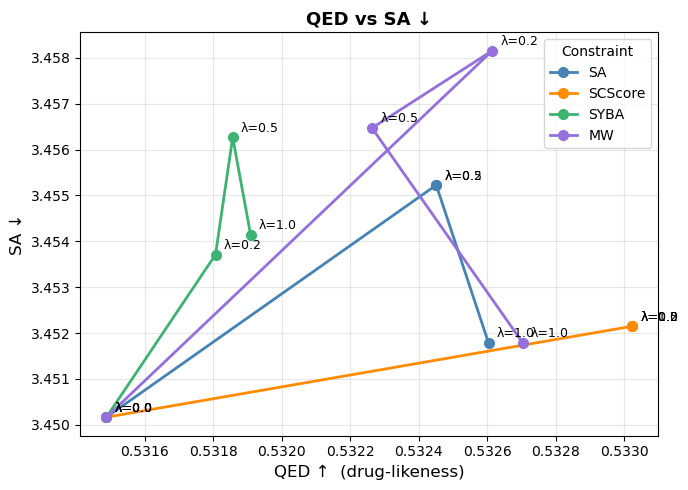

Saved ablation_pareto_mean_sa.png


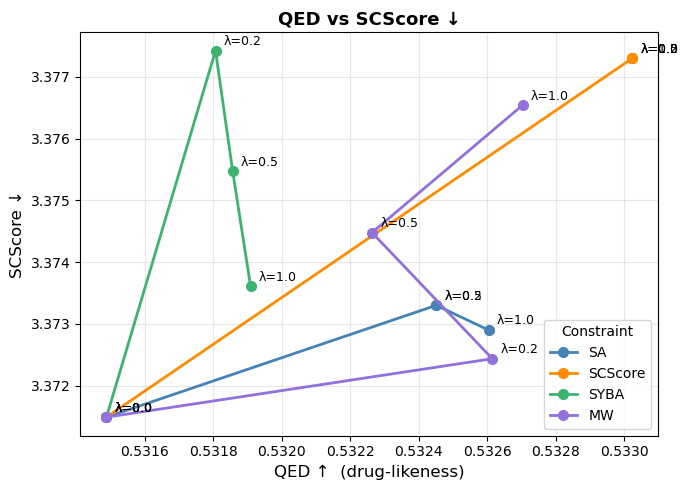

Saved ablation_pareto_mean_scscore.png


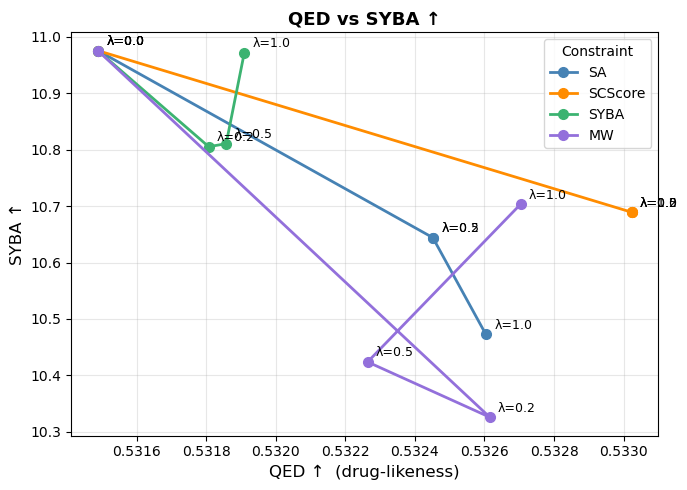

Saved ablation_pareto_mean_syba.png


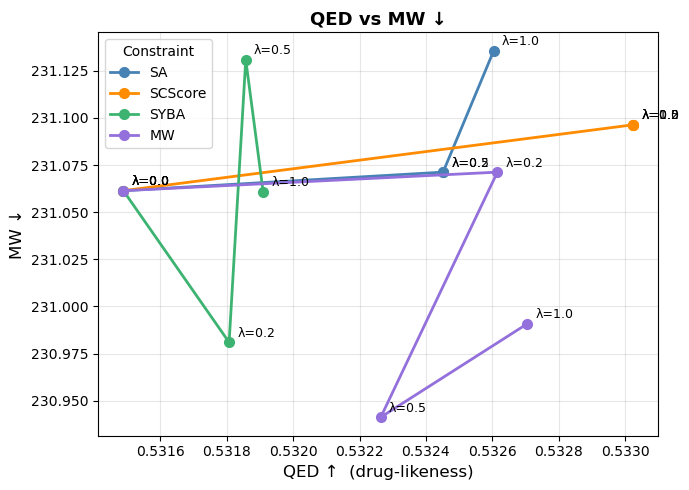

Saved ablation_pareto_mean_mw.png


In [60]:
import matplotlib.pyplot as plt

colors = {"SA": "steelblue", "SCScore": "darkorange", "SYBA": "mediumseagreen", "MW": "mediumpurple"}
pareto_metrics = [
    ("mean_sa",      metric_labels["mean_sa"]),
    ("mean_scscore", metric_labels["mean_scscore"]),
    ("mean_syba",    metric_labels["mean_syba"]),
    ("mean_mw",      metric_labels["mean_mw"]),
]

for metric, ylabel in pareto_metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    for cost_name in cost_fns:
        sub = ablation_df[ablation_df["optimized_cost"] == cost_name].sort_values("λ")
        ax.plot(sub["mean_qed"], sub[metric], marker="o", color=colors[cost_name],
                label=cost_name, linewidth=2, markersize=7)
        for _, r in sub.iterrows():
            ax.annotate(f"λ={r['λ']}", (r["mean_qed"], r[metric]),
                        fontsize=9, xytext=(6, 4), textcoords="offset points")
    ax.set_xlabel("QED ↑  (drug-likeness)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"QED vs {ylabel}", fontsize=13, fontweight="bold")
    ax.legend(title="Constraint", fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"ablation_pareto_{metric}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved {fname}")


## Part 3 — Property Predictor Calibration Check

Encodes held-out molecules and compares predicted vs RDKit-computed QED and SA.  
R² > 0.7 on both validates that gradient ascent meaningfully steers latent vectors.


In [61]:
from sklearn.metrics import r2_score
import numpy as np

HELD_OUT_N   = 500
TRAIN_OFFSET = 500_000
held_out = []
with open(CSV_PATH) as f:
    next(f)
    for i, line in enumerate(f):
        if i >= TRAIN_OFFSET:
            smi = line.strip()
            if smi:
                held_out.append(smi)
        if len(held_out) >= HELD_OUT_N:
            break
print(f"Held-out set: {len(held_out)} molecules")

Held-out set: 500 molecules


In [ ]:
from rdkit import Chem
from rdkit.Chem import QED as rdkit_QED
import rdkit, sys as _sys
_contrib = _os.path.join(rdkit.__path__[0], "Contrib")
if _contrib not in _sys.path:
    _sys.path.insert(0, _contrib)
from SA_Score import sascorer

valid_held = [s for s in held_out if Chem.MolFromSmiles(s) is not None]
true_qed = [float(rdkit_QED.qed(Chem.MolFromSmiles(s))) for s in valid_held]
true_sa  = [float(sascorer.calculateScore(Chem.MolFromSmiles(s))) for s in valid_held]

mu_held = vae.encode(valid_held, tok, device, batch_size=128)
pred_qed_vals = pred_qed.predict_qed(mu_held).squeeze().cpu().detach().numpy()
pred_sa_vals  = pred_sa.predict_sa(mu_held).squeeze().cpu().detach().numpy()

r2_qed = r2_score(true_qed, pred_qed_vals)
r2_sa  = r2_score(true_sa,  pred_sa_vals)
print(f"R²  QED: {r2_qed}   (> 0.7 needed for reliable gradient ascent)")
print(f"R²  SA:  {r2_sa}   (> 0.7 needed for reliable gradient ascent)")

R²  QED: -0.004   (> 0.7 needed for reliable gradient ascent)
R²  SA:  -3.190   (> 0.7 needed for reliable gradient ascent)


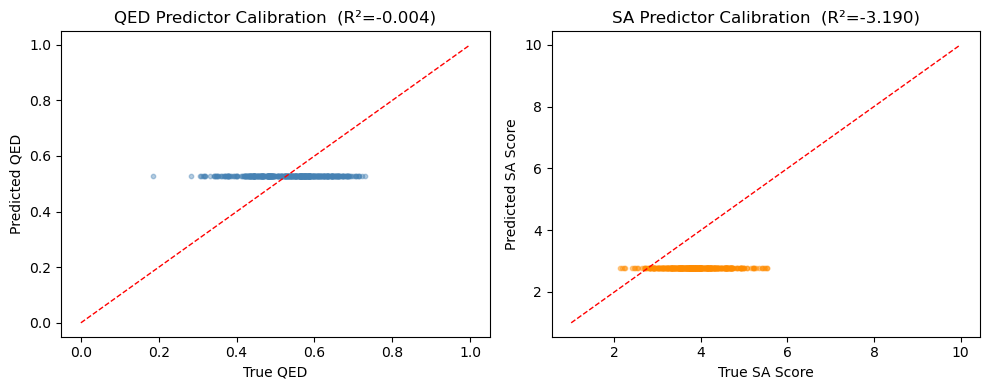

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_qed, pred_qed_vals, alpha=0.4, s=10, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r--", lw=1)
axes[0].set_xlabel("True QED"); axes[0].set_ylabel("Predicted QED")
axes[0].set_title(f"QED Predictor Calibration  (R²={r2_qed})")

axes[1].scatter(true_sa, pred_sa_vals, alpha=0.4, s=10, color="darkorange")
axes[1].plot([1, 10], [1, 10], "r--", lw=1)
axes[1].set_xlabel("True SA Score"); axes[1].set_ylabel("Predicted SA Score")
axes[1].set_title(f"SA Predictor Calibration  (R²={r2_sa})")

plt.tight_layout()
plt.savefig("predictor_calibration.png", dpi=150)
plt.show()

## Part 4 — Additional Experiments


### Using Hard SA Feasibility Threshold To Filter Generation
Fraction of generated molecules with SA ≤ 4, across all ablation models.


In [ ]:
from evaluate import feasibility_rate

print(f"{'model':<22}  feasibility (SA≤4)")
print("-" * 42)
m = ablation_metrics[("LSTM", None)]
rate, _ = feasibility_rate(ablation_smiles[("LSTM", None)], sa_threshold=4.0)
print(f"{'LSTM baseline':<22}  {rate:.3f}")
for cost_name in cost_fns:
    for lam in LAMBDAS:
        rate, _ = feasibility_rate(ablation_smiles[(cost_name, lam)], sa_threshold=4.0)
        print(f"  {cost_name:<8} λ={lam:<4}       {rate:.3f}")

### Combined Multi-Constraint

Generate with combined 4 constraints (equal weight).

In [ ]:
LAMBDA_COMBINED = 0.5
per_term = LAMBDA_COMBINED / 4

cost_terms_combined = [
    (lambda z: (pred_sa.predict_sa(z) - 1.0) / 9.0,  per_term),
    (lambda z: torch.sigmoid(pred_scscore(z)),          per_term),
    (lambda z: 1.0 - torch.sigmoid(pred_syba(z)),       per_term),
    (lambda z: torch.sigmoid(pred_mw(z)),               per_term),
]

gen_combined = ConstrainedGenerator(vae, pred_qed, pred_sa, tok,
                                     beta=BETA_ANCHOR, device=device,
                                     cost_terms=cost_terms_combined)
smiles_combined = gen_combined.generate(N_MOLECULES, n_steps=GA_STEPS,
                                         ga_lr=GA_LR, temperature=TEMPERATURE)

m_combined = compute_ablation_metrics(smiles_combined)
m_sa_05    = ablation_metrics[("SA", 0.5)]

print(f"{'metric'}  {'SA λ=0.5 (baseline)'}  {'Combined λ=0.5'}")
print("-" * 56)
for k in metrics_keys:
    print(f"{k}  {m_sa_05[k]}  {m_combined[k]}")

---
### References
- Cyclic KL annealing: https://arxiv.org/abs/1903.10145
- VAE: https://arxiv.org/abs/1312.6114
- SMILES VAE: https://arxiv.org/abs/1610.02415
- SMILES tokenization (Molecular Transformer): https://arxiv.org/abs/1811.02633
- SCS Score: https://pubs.acs.org/doi/10.1021/acs.jcim.7b00622
- SYBA: https://pmc.ncbi.nlm.nih.gov/articles/PMC7238540/ 
